### arHMM example (t cell dynamics)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
example_emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_gt_crop/example_t_cell_emissions_array.npy")

In [4]:
key1, key2 = jr.split(jr.PRNGKey(0), 2)
num_states = 3
emission_dim = 3
num_lags = 1

In [5]:
example_emissions.shape

(50, 110, 3)

In [42]:
batched_example_emissions = np.transpose(example_emissions, (1, 0, 2)) # shape (num_samples, time_bins, emission_dim)
batched_example_emissions.shape

(110, 50, 3)

In [7]:
one_sample_emissions = example_emissions[:, 0, :] # shape (time_bins, emission_dim)
one_sample_emissions.shape

(50, 3)

In [ ]:
# batch_list = []
# for cell in range(example_emissions.shape[1]):
#     batch_list.append(example_emissions[:, cell, :])

# batch_emissions = jnp.array(batch_list)

In [ ]:
# batch_emissions.shape

(110, 50, 3)

In [ ]:
# batch_emissions.reshape(1,*batch_emissions.shape).shape

(1, 110, 50, 3)

In [17]:
active_rows = ~(one_sample_emissions == 0).all(axis=1)

In [19]:
one_sample_emissions = one_sample_emissions[active_rows]

In [25]:
one_sample_emissions.shape

(26, 3)

In [26]:
# # Initialize with K-Means
# arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
# params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=batch_emissions)
# inputs = arhmm.compute_inputs(batch_emissions)

# Initialize with K-Means
arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=one_sample_emissions)
inputs = arhmm.compute_inputs(one_sample_emissions)

In [27]:
# Fit with EM
fitted_params, lps = arhmm.fit_em(params, props, one_sample_emissions, inputs=inputs)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;00:00]</div>

In [28]:
lps

Array([-69.84123,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan], dtype=float32)

### experiment with batching

<div><progress max="20" value="20"></progress> 100.00% [20/20 00:00&lt;00:00]</div>

(1000, 3)


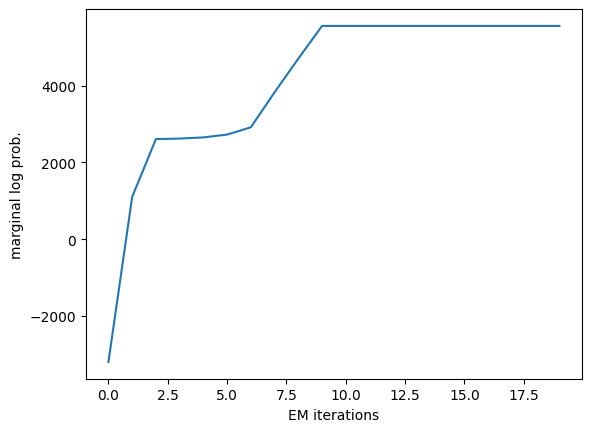

In [31]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from dynamax.hidden_markov_model import GaussianHMM

key1, key2, key3 = jr.split(jr.PRNGKey(0), 3)
num_states = 3
emission_dim = 2
num_timesteps = 1000

# Make a Gaussian HMM and sample data from it
hmm = GaussianHMM(num_states, emission_dim)
true_params, _ = hmm.initialize(key1)
true_states, emissions = hmm.sample(true_params, key2, num_timesteps)

# Make a new Gaussian HMM and fit it with EM
params, props = hmm.initialize(key3, method="kmeans", emissions=emissions)
params, lls = hmm.fit_em(params, props, emissions, num_iters=20)

# Plot the marginal log probs across EM iterations
plt.plot(lls)
plt.xlabel("EM iterations")
plt.ylabel("marginal log prob.")

# Use fitted model for posterior inference
post = hmm.smoother(params, emissions)
print(post.smoothed_probs.shape) # (1000, 3)

In [32]:
from functools import partial
from jax import vmap

num_seq = 200
batch_true_states, batch_emissions = \
    vmap(partial(hmm.sample, true_params, num_timesteps=num_timesteps))(
        jr.split(key2, num_seq))
print(batch_true_states.shape, batch_emissions.shape) # (200,1000) and (200,1000,2)

# Make a new Gaussian HMM and fit it with EM
params, props = hmm.initialize(key3, method="kmeans", emissions=batch_emissions)
params, lls = hmm.fit_em(params, props, batch_emissions, num_iters=20)

(200, 1000) (200, 1000, 2)


<div><progress max="20" value="20"></progress> 100.00% [20/20 00:01&lt;00:00]</div>

In [35]:
batch_emissions.shape

(200, 1000, 2)

In [36]:
batch_emissions.reshape(-1, 2).shape

(200000, 2)

In [40]:
batch_emissions.reshape(1, *batch_emissions.shape).shape

(1, 200, 1000, 2)

### create new batching for example

In [44]:
batched_example_emissions = np.transpose(example_emissions, (1, 0, 2)) # shape (num_samples, time_bins, emission_dim)
batched_example_emissions.shape

(110, 50, 3)

In [54]:
active_rows = ~(batched_example_emissions == 0).all(axis=2) # shape (num_samples, time_bins) boolean array indicating which rows have nonzero emissions

In [60]:
active_batched_example_emissions = batched_example_emissions[active_rows, :]
active_batched_example_emissions.shape

(2168, 3)

In [45]:
key1, key2 = jr.split(jr.PRNGKey(0), 2)
num_states = 3
emission_dim = 3
num_lags = 1

In [47]:
# Initialize with K-Means
arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=batched_example_emissions)
inputs = vmap(arhmm.compute_inputs)(batched_example_emissions)

In [49]:
# Fit with EM
fitted_params, lps = arhmm.fit_em(params, props, batched_example_emissions, inputs=inputs)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;00:00]</div>

In [66]:
fitted_params

ParamsLinearAutoregressiveHMM(initial=ParamsStandardHMMInitialState(probs=Array([nan, nan, nan], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]], dtype=float32)), emissions=ParamsLinearRegressionHMMEmissions(weights=Array([[[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]]], dtype=float32), biases=Array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]], dtype=float32), covs=Array([[[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]]], dtype=float32)))

Text(0, 0.5, 'marginal log prob.')

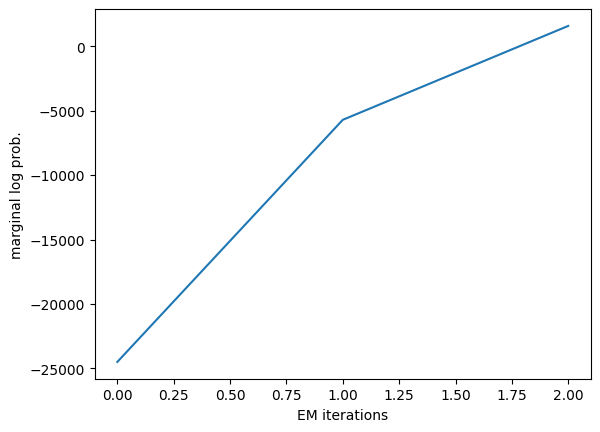

In [61]:
plt.plot(lps)
plt.xlabel("EM iterations")
plt.ylabel("marginal log prob.")

In [68]:
print(f"emissions.shape: {batched_example_emissions.shape}")
print(f"inputs.shape: {inputs.shape}")

emissions.shape: (110, 50, 3)
inputs.shape: (110, 50, 3)


In [70]:
#posterior = arhmm.smoother(fitted_params, emissions, inputs=inputs)

from functools import partial
posterior = vmap(partial(arhmm.smoother, fitted_params))(batched_example_emissions, inputs)
# OR run posterior = vmap(lambda e, u: arhmm.smoother(fitted_params, e, inputs=u))(batched_example_emissions, inputs)

In [76]:
posterior.smoothed_probs.shape

(110, 50, 3)

Text(0.5, 0, 'time')

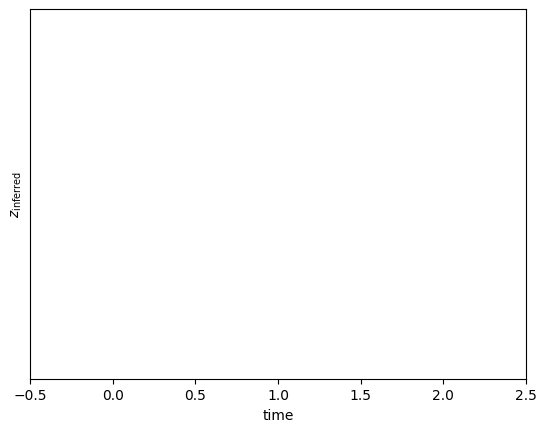

In [77]:
plt.imshow(posterior.smoothed_probs[0], aspect="auto", interpolation="none", cmap="Greys", vmin=0, vmax=1)
plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")


In [81]:
fully_active_mask = active_rows.all(axis=1)  # (num_samples,) — True only if cell is active ALL timesteps
fully_active_emissions = batched_example_emissions[fully_active_mask]  # (n_fully_active, time_bins, emission_dim)
print(f"{fully_active_mask.sum()} / {len(fully_active_mask)} cells fully active")

arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=fully_active_emissions)
inputs = vmap(arhmm.compute_inputs)(fully_active_emissions)
fitted_params, lps = arhmm.fit_em(params, props, fully_active_emissions, inputs=inputs)

12 / 110 cells fully active


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;00:00]</div>

In [88]:
lps

Array([-2714.6912, -1396.1577,  -854.9435,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan],      dtype=float32)